In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import wfdb
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate

In [2]:
def load_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    #metadata = data
    data = np.array([signal for signal, meta in data])
    #return data, metadata
    return data

path = '../dataset/ptb_xl/'
sampling_rate=100

# load and convert annotation datas
Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))
print("Available folds:", Y.strat_fold.unique())
print("Number of folds:", len(Y.strat_fold.unique()))
# Load raw signal data
#X, metadata = load_data(Y, sampling_rate, path)
X = load_data(Y, sampling_rate, path)
# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)

agg_df = agg_df[agg_df.diagnostic == 1]

#def aggregate_diagnostic_superclass(y_dic):
#    tmp = []
#    for key in y_dic.keys():
#        if key in agg_df.index:
#            tmp.append(agg_df.loc[key].diagnostic_class)
#    return list(set(tmp))

def aggregate_diagnostic_subclass(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_subclass)
    return list(set(tmp))
# Apply diagnostic superclass
#Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic_superclass)
Y['diagnostic_subclass'] = Y.scp_codes.apply(aggregate_diagnostic_subclass)
# Split data into train and test
test_fold = 10
# Train
X_train = X[np.where(Y.strat_fold != test_fold)]
#y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
y_train_sub = Y[Y.strat_fold != test_fold].diagnostic_subclass
# Test
X_test = X[np.where(Y.strat_fold == test_fold)]
#y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass
y_test_sub = Y[Y.strat_fold == test_fold].diagnostic_subclass

Available folds: [ 3  2  5  4  7  9 10  8  6  1]
Number of folds: 10


In [3]:
# Show all rows without truncation
pd.set_option('display.max_rows', None)

# If you also want to prevent truncation horizontally (for wide content):
pd.set_option('display.max_colwidth', None)  # Or a large number

label_map_sub = {
 'NORM': 0, 'LAFB/LPFB': 1, 'IRBBB': 2, 'ILBBB': 3, 'CLBBB': 4,
 'CRBBB': 5, '_AVB': 6, 'IVCB': 7, 'WPW': 8, 'LVH': 9, 'RHV': 10,
 'LAO/LAE': 11, 'RAO/RAE': 12, 'SEHYP': 13, 'AMI': 14, 'IMI': 15,
 'LMI': 16, 'PMI': 17, 'ISCA': 18, 'ISCI': 19, 'ISC_': 20,
 'STTC': 21, 'NST_': 22
}

# Convert and filter
def mapping_label_and_filter_signals_np(signals: np.ndarray, labels: list, label_map: dict = label_map_sub):
    converted_labels = []
    valid_indices = []
    
    for i, lbl_list in enumerate(labels):
        if lbl_list:  # skip empty labels
            mapped = [label_map[label] for label in lbl_list if label in label_map]
            converted_labels.append(mapped)
            valid_indices.append(i)
    
    # Use valid indices to slice the numpy signals array
    filtered_signals = signals[valid_indices, :, :]
    
    return filtered_signals, converted_labels

In [4]:
X_train_, y_train_ = mapping_label_and_filter_signals_np(X_train, y_train_sub)
y_train_ = pd.Series(y_train_)
#counts_train_label = y_train_.value_counts().sort_index()  # Sort by class label (0 → 4)
#print(counts_train_label)
X_test_, y_test_ = mapping_label_and_filter_signals_np(X_test, y_test_sub)
y_test_ = pd.Series(y_test_)
#counts = y_test_.value_counts().sort_index()  # Sort by class label (0 → 4)
#print(counts)

def labels_to_multihot(label_list, num_classes=23):
    y = torch.zeros((len(label_list), num_classes))
    for i, labels in enumerate(label_list):
        y[i, labels] = 1
    return y

y_train_one_hot = labels_to_multihot(y_train_, num_classes=23)  
y_test_one_hot = labels_to_multihot(y_test_, num_classes=23)  
counts = y_test_.value_counts()  # Sort by class label (0 → 4)
print(counts)


[0]                    929
[15]                   150
[21]                   148
[14]                    70
[9]                     50
[14, 15]                46
[1]                     45
[9, 20]                 38
[4]                     38
[2]                     37
[22]                    36
[18]                    31
[2, 0]                  22
[1, 14]                 21
[9, 14, 20]             19
[]                      15
[18, 14]                13
[9, 15, 20]             13
[5]                     12
[18, 19]                11
[19]                    11
[18, 15]                10
[21, 15]                10
[6, 14]                  9
[1, 14, 15]              9
[1, 15]                  9
[9, 21]                  9
[2, 1]                   8
[8]                      8
[5, 1]                   8
[20]                     7
[6]                      7
[9, 14]                  7
[6, 15]                  7
[1, 21]                  6
[21, 14]                 6
[2, 14, 15]              6
[

In [5]:
x_train = torch.from_numpy(X_train_).float()  # float tensor for input
train, val, labels_train, labels_val = train_test_split(
    x_train, y_train_one_hot, test_size=0.2, random_state=42, shuffle=True
)
x_test = torch.from_numpy(X_test_).float()

batch_size = 32

train_dataset = TensorDataset(train, labels_train)
val_dataset = TensorDataset(val, labels_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test = TensorDataset(x_test, y_test_one_hot)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

In [7]:
import torch
import torch.nn as nn

class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_sizes=[3,3], pooling_kernel=2):
        super().__init__()
        layers = []
        for i, k in enumerate(kernel_sizes):
            layers.append(nn.Conv1d(in_channels if i == 0 else out_channels, out_channels, kernel_size=k, padding=k//2))
            layers.append(nn.LeakyReLU(negative_slope=0.01))
        layers.append(nn.AvgPool1d(pooling_kernel))
        self.block = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.block(x)

class MultiStageCNNLSTM(nn.Module):
    def __init__(self, in_channels=12, num_classes=23, lstm_hidden_size=64, lstm_layers=1):
        super().__init__()
        
        # First 2 CNN layers block
        self.cnn_block1 = CNNBlock(in_channels, 32, kernel_sizes=[7,5])
        
        # First LSTM layer
        self.lstm1 = nn.LSTM(input_size=32, hidden_size=lstm_hidden_size, num_layers=lstm_layers,
                             batch_first=False, bidirectional=True)
        
        # Second 2 CNN layers block
        self.cnn_block2 = CNNBlock(lstm_hidden_size * 2, 64, kernel_sizes=[5,3])
        
        # Second LSTM layer
        self.lstm2 = nn.LSTM(input_size=64, hidden_size=lstm_hidden_size, num_layers=lstm_layers,
                             batch_first=False, bidirectional=True)
        
        # Third 2 CNN layers block
        self.cnn_block3 = CNNBlock(lstm_hidden_size * 2, 128, kernel_sizes=[3,3])
        
        # Fully connected head
        self.fc_layers = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),  # output shape (batch, 128, 1)
            nn.Flatten(),             # (batch, 128)
            nn.Linear(128, 64),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        # x: (batch, channels, seq_len)
        x = self.cnn_block1(x)  # (batch, 32, L)
        
        # LSTM1 expects (seq_len, batch, features)
        x = x.permute(2, 0, 1)  # (L, batch, 32)
        x, _ = self.lstm1(x)    # (L, batch, hidden*2)
        
        # back to CNN format (batch, channels, seq_len)
        x = x.permute(1, 2, 0)  # (batch, hidden*2, L)
        
        x = self.cnn_block2(x)  # (batch, 64, L2)
        
        x = x.permute(2, 0, 1)  # (L2, batch, 64)
        x, _ = self.lstm2(x)    # (L2, batch, hidden*2)
        
        x = x.permute(1, 2, 0)  # (batch, hidden*2, L2)
        
        x = self.cnn_block3(x)  # (batch, 128, L3)
        
        out = self.fc_layers(x)  # (batch, num_classes)
        return out

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MultiStageCNNLSTM(num_classes=23).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

In [9]:
# 4. Training loop
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs.transpose(1, 2))  # CNN expects (batch, channels, seq_len)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs.transpose(1, 2))
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)

    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

model.eval()
test_loss = 0.0
criterion = nn.BCEWithLogitsLoss()  # or your chosen loss

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs.transpose(1, 2))
        loss = criterion(outputs, targets)
        test_loss += loss.item() * inputs.size(0)

test_loss /= len(test_loader.dataset)
print(f"Test Loss: {test_loss:.4f}")

Epoch 1/50, Train Loss: 0.1922, Val Loss: 0.1494
Epoch 2/50, Train Loss: 0.1451, Val Loss: 0.1446
Epoch 3/50, Train Loss: 0.1419, Val Loss: 0.1370
Epoch 4/50, Train Loss: 0.1338, Val Loss: 0.1281
Epoch 5/50, Train Loss: 0.1269, Val Loss: 0.1264
Epoch 6/50, Train Loss: 0.1231, Val Loss: 0.1197
Epoch 7/50, Train Loss: 0.1194, Val Loss: 0.1160
Epoch 8/50, Train Loss: 0.1169, Val Loss: 0.1135
Epoch 9/50, Train Loss: 0.1143, Val Loss: 0.1118
Epoch 10/50, Train Loss: 0.1111, Val Loss: 0.1118
Epoch 11/50, Train Loss: 0.1090, Val Loss: 0.1084
Epoch 12/50, Train Loss: 0.1067, Val Loss: 0.1064
Epoch 13/50, Train Loss: 0.1083, Val Loss: 0.1070
Epoch 14/50, Train Loss: 0.1069, Val Loss: 0.1064
Epoch 15/50, Train Loss: 0.1038, Val Loss: 0.1037
Epoch 16/50, Train Loss: 0.1016, Val Loss: 0.1029
Epoch 17/50, Train Loss: 0.0989, Val Loss: 0.1005
Epoch 18/50, Train Loss: 0.0980, Val Loss: 0.0990
Epoch 19/50, Train Loss: 0.0967, Val Loss: 0.0997
Epoch 20/50, Train Loss: 0.0954, Val Loss: 0.0971
Epoch 21/

In [10]:
def performance_evaluation(model=model, dataset = test_loader, dataset_name = "Test Set"):
    
    all_targets = []
    all_preds = []

    model.eval()
    with torch.no_grad():
        for inputs, targets in dataset:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs.transpose(1, 2))
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)

    num_classes = all_targets.shape[1]

    # Prepare table data
    table_data = []
    headers = ["Class", "Precision", "Recall (Sensitivity)", "Specificity", "TN", "FP", "FN", "TP"]

    for i in range(num_classes):
        y_true = all_targets[:, i]
        y_pred = all_preds[:, i]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        if cm.size == 4:
            TN, FP, FN, TP = cm.ravel()
            total = TN + FP + FN + TP
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0

            # Format with percentage
            TN_str = f"{TN} ({TN/total*100:.1f}%)"
            FP_str = f"{FP} ({FP/total*100:.1f}%)"
            FN_str = f"{FN} ({FN/total*100:.1f}%)"
            TP_str = f"{TP} ({TP/total*100:.1f}%)"
        else:
            TN_str = FP_str = FN_str = TP_str = "0 (0.0%)"
            specificity = 0.0

        table_data.append([
            i,
            f"{precision:.4f}",
            f"{recall:.4f}",
            f"{specificity:.4f}",
            TN_str,
            FP_str,
            FN_str,
            TP_str,
        ])
    print(f"\n------------Performance Evaluation Metrics per Class({dataset_name}) -----------\n")
    print(tabulate(table_data, headers=headers, tablefmt="grid"))
    return all_targets, all_preds

In [11]:
targets_train, preds_train = performance_evaluation(model, train_loader, "Train Set")
targets_val, preds_val = performance_evaluation(model, val_loader, "Val Set")
targets_test, preds_test = performance_evaluation(model, test_loader, "Test Set")

/home/alex/dev/ecg-signal-processing/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/alex/dev/ecg-signal-processing/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



------------Performance Evaluation Metrics per Class(Train Set) -----------

+---------+-------------+------------------------+---------------+---------------+------------+------------+--------------+
|   Class |   Precision |   Recall (Sensitivity) |   Specificity | TN            | FP         | FN         | TP           |
+=========+=============+========================+===============+===============+============+============+==============+
|       0 |      0.9457 |                 0.913  |        0.9583 | 8211 (53.4%)  | 357 (2.3%) | 593 (3.9%) | 6223 (40.5%) |
+---------+-------------+------------------------+---------------+---------------+------------+------------+--------------+
|       1 |      0.8753 |                 0.8733 |        0.9887 | 13938 (90.6%) | 160 (1.0%) | 163 (1.1%) | 1123 (7.3%)  |
+---------+-------------+------------------------+---------------+---------------+------------+------------+--------------+
|       2 |      0.8372 |                 0.6764 |    

/home/alex/dev/ecg-signal-processing/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/alex/dev/ecg-signal-processing/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



------------Performance Evaluation Metrics per Class(Val Set) -----------

+---------+-------------+------------------------+---------------+--------------+------------+------------+--------------+
|   Class |   Precision |   Recall (Sensitivity) |   Specificity | TN           | FP         | FN         | TP           |
+=========+=============+========================+===============+==============+============+============+==============+
|       0 |      0.8712 |                 0.834  |        0.8986 | 1897 (49.3%) | 214 (5.6%) | 288 (7.5%) | 1447 (37.6%) |
+---------+-------------+------------------------+---------------+--------------+------------+------------+--------------+
|       1 |      0.7259 |                 0.7259 |        0.9741 | 3423 (89.0%) | 91 (2.4%)  | 91 (2.4%)  | 241 (6.3%)   |
+---------+-------------+------------------------+---------------+--------------+------------+------------+--------------+
|       2 |      0.702  |                 0.493  |        0.987

/home/alex/dev/ecg-signal-processing/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/alex/dev/ecg-signal-processing/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [12]:
def plot_confusion_matrix_per_class(y_true, y_pred, class_names=None):
    num_classes = y_true.shape[1]
    
    for i in range(num_classes):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i])
        total = np.sum(cm)
        
        # Prepare annotation with counts and percentages
        if cm.size == 4:
            annot = np.empty_like(cm).astype(str)
            for r in range(2):
                for c in range(2):
                    count = cm[r, c]
                    pct = 100 * count / total if total > 0 else 0
                    annot[r, c] = f"{count}\n({pct:.1f}%)"
        else:
            annot = cm
        
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
                    xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
        
        title = f'Confusion Matrix - Class {i}' if class_names is None else f'Confusion Matrix - {class_names[i]}'
        plt.title(title)
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.show()

# Example usage with numpy arrays all_targets and all_preds
classes_name_sub = {
 'NORM': 0, 'LAFB/LPFB': 1, 'IRBBB': 2, 'ILBBB': 3, 'CLBBB': 4,
 'CRBBB': 5, '_AVB': 6, 'IVCB': 7, 'WPW': 8, 'LVH': 9, 'RHV': 10,
 'LAO/LAE': 11, 'RAO/RAE': 12, 'SEHYP': 13, 'AMI': 14, 'IMI': 15,
 'LMI': 16, 'PMI': 17, 'ISCA': 18, 'ISCI': 19, 'ISC_': 20,
 'STTC': 21, 'NST_': 22
}

confusion_matrix (Test Set)


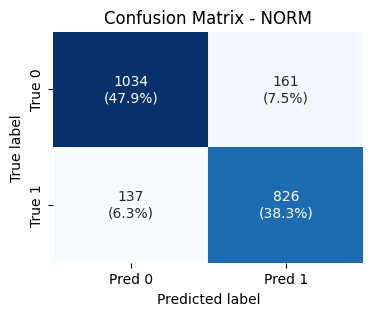

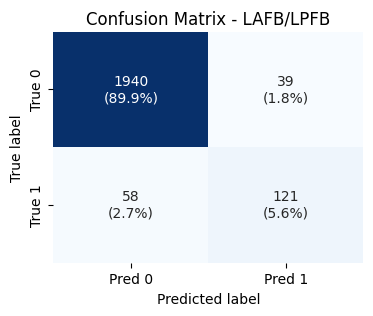

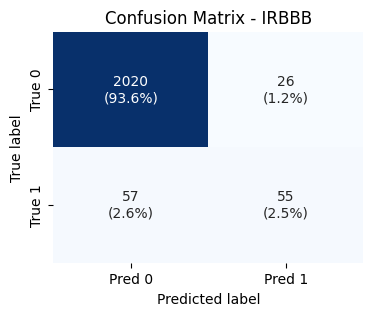

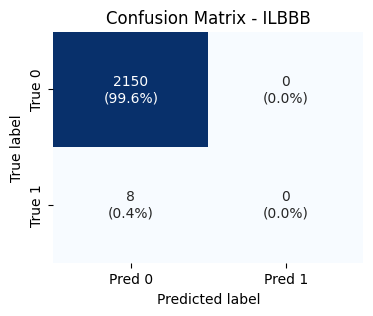

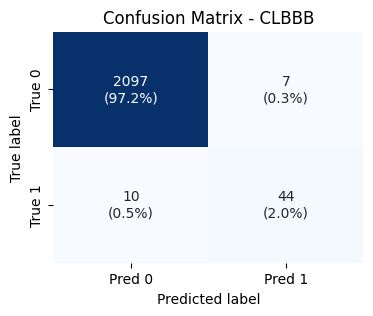

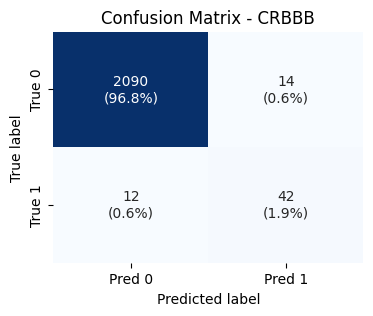

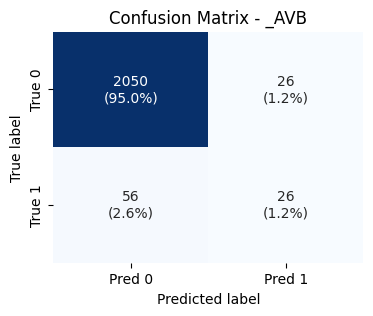

/home/alex/dev/ecg-signal-processing/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


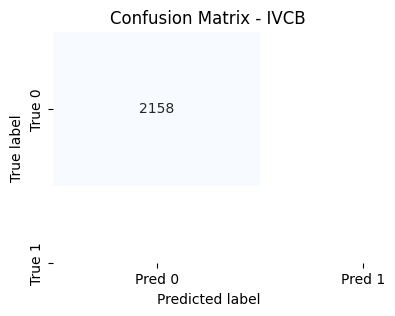

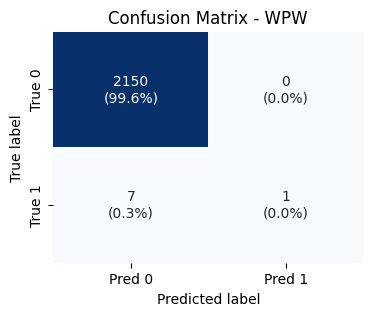

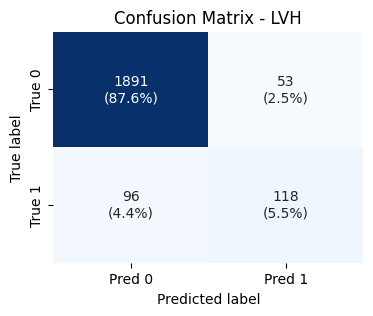

/home/alex/dev/ecg-signal-processing/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


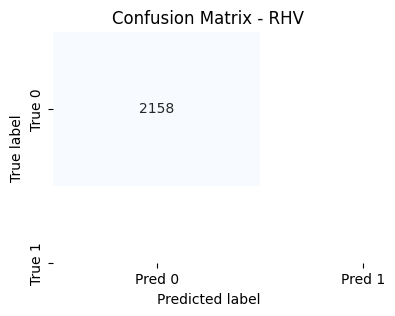

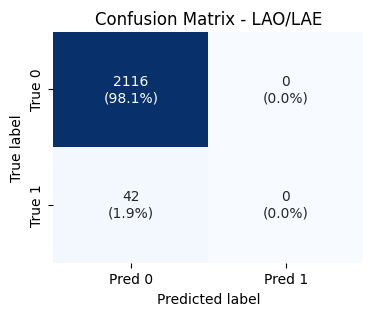

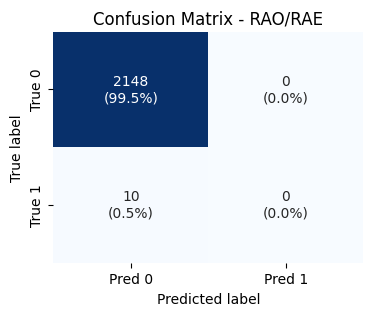

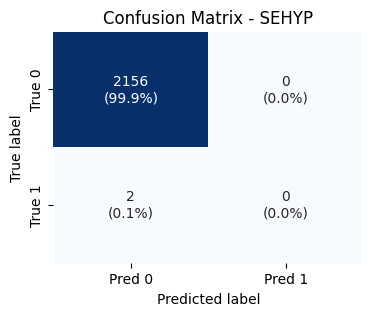

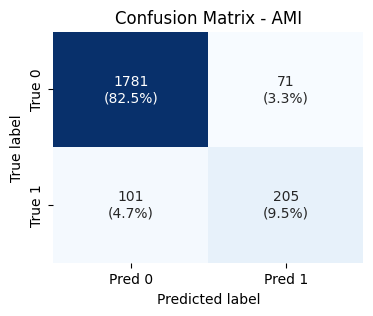

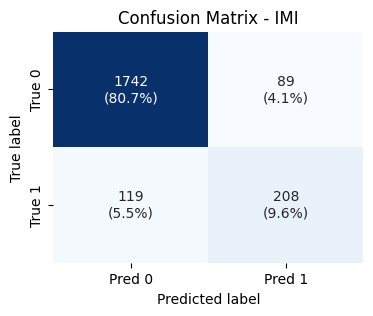

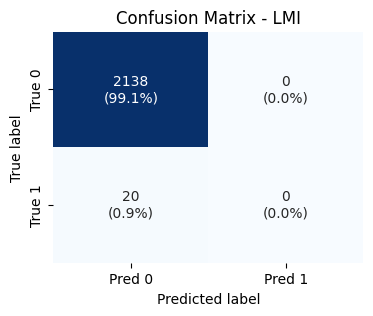

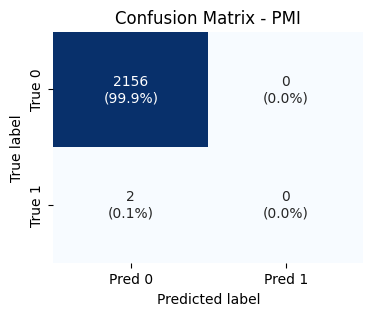

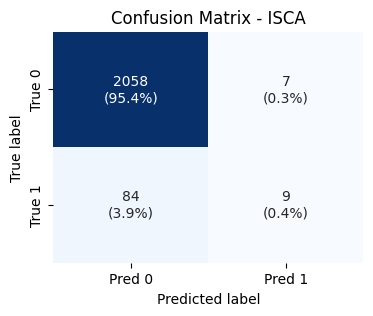

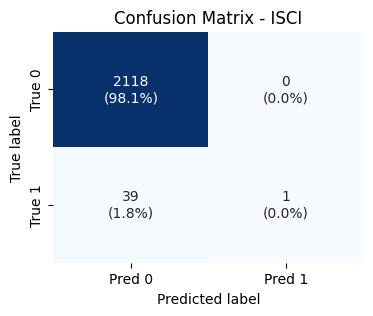

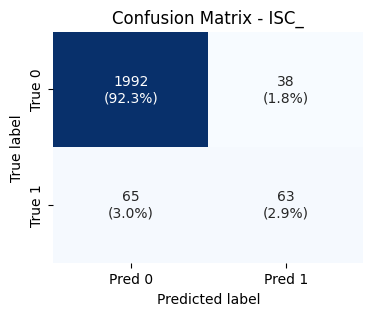

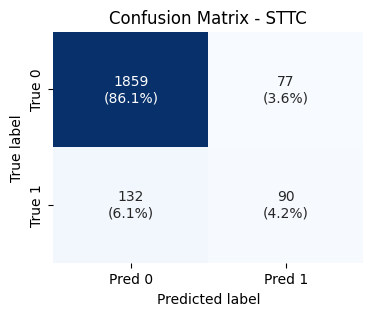

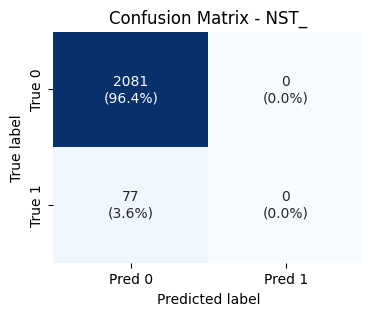

In [13]:
print("confusion_matrix (Test Set)")
plot_confusion_matrix_per_class(targets_test, preds_test, list(classes_name_sub.keys()))